In [1]:
%matplotlib inline
# Cell 1 — parameters and fixtures

LAT = 16.8167   # Timbuktu (anchor; L06 hybas_id = 1060551560 confirmed)
LON = -2.9833

# Three fixtures for breadth — Niger bend, Mediterranean, Tigris-Euphrates
FIXTURES = [
    {'name': 'Timbuktu', 'lat': 16.8167, 'lon': -2.9833},
    {'name': 'Rome',     'lat': 41.9,    'lon': 12.5},
    {'name': 'Baghdad',  'lat': 33.3,    'lon': 44.4},
]

In [2]:
# Cell 2 — imports and connection
import sys
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import Normalize
from shapely import wkt as shapely_wkt
from pathlib import Path
from IPython.display import Image as IPImage, display

sys.path.insert(0, '../../../..')
from scripts.shared.db_utils import db_connect
import scripts.shared.db_utils as _dbu

ROOT = Path(_dbu.__file__).parent.parent.parent
OUT  = ROOT / 'output' / 'edop' / 'areas'
OUT.mkdir(parents=True, exist_ok=True)

conn = db_connect()
print('Connected:', conn.execute('SELECT current_database()').fetchone()[0])

Connected: cedop


In [3]:
# Cell 3 — containing basin (L06) for each fixture

fixtures_l06 = []
for fx in FIXTURES:
    sql = (
        f"SELECT hybas_id, sub_area AS sub_area_km2 "
        f"FROM public.basin06 "
        f"WHERE ST_Contains(geom, ST_SetSRID(ST_MakePoint({fx['lon']}, {fx['lat']}), 4326))"
    )
    df = pd.read_sql(sql, conn)
    if df.empty:
        print(f"WARNING: no basin found for {fx['name']}")
        continue
    hid  = int(df['hybas_id'].iloc[0])
    area = float(df['sub_area_km2'].iloc[0])
    fixtures_l06.append({'name': fx['name'], 'lat': fx['lat'], 'lon': fx['lon'],
                          'hybas_id': hid, 'sub_area_km2': area})
    print(f"{fx['name']:10s}  hybas_id={hid}  sub_area={area:,.0f} km²")

assert int([r for r in fixtures_l06 if r['name'] == 'Timbuktu'][0]['hybas_id']) == 1060551560
print('\nTimbuktu L06 hybas_id confirmed: 1060551560')

Timbuktu    hybas_id=1060551560  sub_area=3,826 km²
Rome        hybas_id=2060015610  sub_area=17,733 km²
Baghdad     hybas_id=2060773460  sub_area=27,142 km²

Timbuktu L06 hybas_id confirmed: 1060551560


In [4]:
# Cell 4 — basin-ring query function
#
# ST_Touches: returns basins whose boundaries share at least one point with the
# center basin but whose interiors do not overlap — the correct predicate for
# polygon adjacency in a topologically clean tiling.
#
# shared_type — PostGIS geometry type of the intersection (ST_MultiLineString
#               for a proper edge contact; ST_Point for a vertex-only contact)
# shared_km   — shared boundary length in km; 0.0 for vertex-only (dim=0)
#               contacts, so callers can distinguish proper edges from artifacts.

def query_ring(center_hybas_id, level, conn):
    table = f'public.basin{level}'
    sql = (
        f"WITH center AS ("
        f"  SELECT geom FROM {table} WHERE hybas_id = {center_hybas_id}"
        f") "
        f"SELECT"
        f"  b.hybas_id,"
        f"  b.sub_area AS sub_area_km2,"
        f"  b.geom,"
        f"  ST_GeometryType(ST_Intersection(b.geom, c.geom)) AS shared_type,"
        f"  CASE"
        f"    WHEN ST_Dimension(ST_Intersection(b.geom, c.geom)) = 1"
        f"    THEN ROUND("
        f"      (ST_Length(ST_Intersection(b.geom, c.geom)::geography) / 1000.0)::numeric, 2"
        f"    )"
        f"    ELSE 0.0"
        f"  END AS shared_km"
        f" FROM {table} b, center c"
        f" WHERE ST_Touches(b.geom, c.geom)"
        f" ORDER BY b.sub_area DESC"
    )
    gdf = gpd.read_postgis(sql, conn, geom_col='geom').rename_geometry('geometry')
    gdf['hybas_id'] = gdf['hybas_id'].astype('int64')
    return gdf

print('query_ring() defined')

query_ring() defined


In [5]:
# Cell 5 — Timbuktu L06: ring query + artifact diagnostics + weight options

CENTER_L06 = 1060551560
ring_l06   = query_ring(CENTER_L06, '06', conn)

print(f'=== Timbuktu L06 ring  (center={CENTER_L06}) ===')
print(f'Ring size: {len(ring_l06)} neighbors')
print()

print('Shared contact geometry types:')
print(ring_l06['shared_type'].value_counts().to_frame('count').to_string())
print()

vertex_only = ring_l06[ring_l06['shared_km'] == 0.0]
if vertex_only.empty:
    print('No vertex-only contacts — all neighbors share a proper edge.  CLEAN')
else:
    print(f'ARTIFACT WARNING: {len(vertex_only)} vertex-only contact(s):')
    print(vertex_only[['hybas_id', 'sub_area_km2', 'shared_type']].to_string(index=False))
print()

print('Ring basin sub_area + shared border:')
print(ring_l06[['sub_area_km2', 'shared_km']].describe().round(1).to_string())
print()

# Three candidate weight schemes for the resolver (display only — no decision yet)
ring_l06 = ring_l06.copy()
ring_l06['w_equal']  = 1.0 / len(ring_l06)
ring_l06['w_area']   = ring_l06['sub_area_km2'] / ring_l06['sub_area_km2'].sum()
ring_l06['w_border'] = ring_l06['shared_km'] / ring_l06['shared_km'].sum()

print('Candidate weight schemes (no decision yet):')
cols = ['hybas_id', 'sub_area_km2', 'shared_km', 'w_equal', 'w_area', 'w_border']
print(ring_l06[cols].round(3).to_string(index=False))

# Seed cross-fixture summary table
timbuktu_info = [r for r in fixtures_l06 if r['name'] == 'Timbuktu'][0]
summary_rows = [{
    'name': 'Timbuktu', 'level': 'L06',
    'hybas_id': CENTER_L06,
    'center_area_km2': timbuktu_info['sub_area_km2'],
    'n_ring': len(ring_l06),
    'n_vertex_only': int((ring_l06['shared_km'] == 0).sum()),
    'min_sub_area_km2': ring_l06['sub_area_km2'].min(),
    'median_sub_area_km2': ring_l06['sub_area_km2'].median(),
    'median_shared_km': float(ring_l06['shared_km'].median()),
}]

=== Timbuktu L06 ring  (center=1060551560) ===
Ring size: 5 neighbors

Shared contact geometry types:
                    count
shared_type              
ST_MultiLineString      5

No vertex-only contacts — all neighbors share a proper edge.  CLEAN

Ring basin sub_area + shared border:
       sub_area_km2  shared_km
count           5.0        5.0
mean        10644.1      109.0
std          9003.5       83.4
min           921.4       19.3
25%          5734.4       61.0
50%         10322.8       80.7
75%         11275.8      153.6
max         24966.0      230.3

Candidate weight schemes (no decision yet):
  hybas_id  sub_area_km2  shared_km  w_equal  w_area  w_border
1060041510       24966.0     230.29      0.2   0.469     0.423
1060564740       11275.8      61.04      0.2   0.212     0.112
1060551770       10322.8     153.56      0.2   0.194     0.282
1060564960        5734.4      80.66      0.2   0.108     0.148
1060550540         921.4      19.32      0.2   0.017     0.035


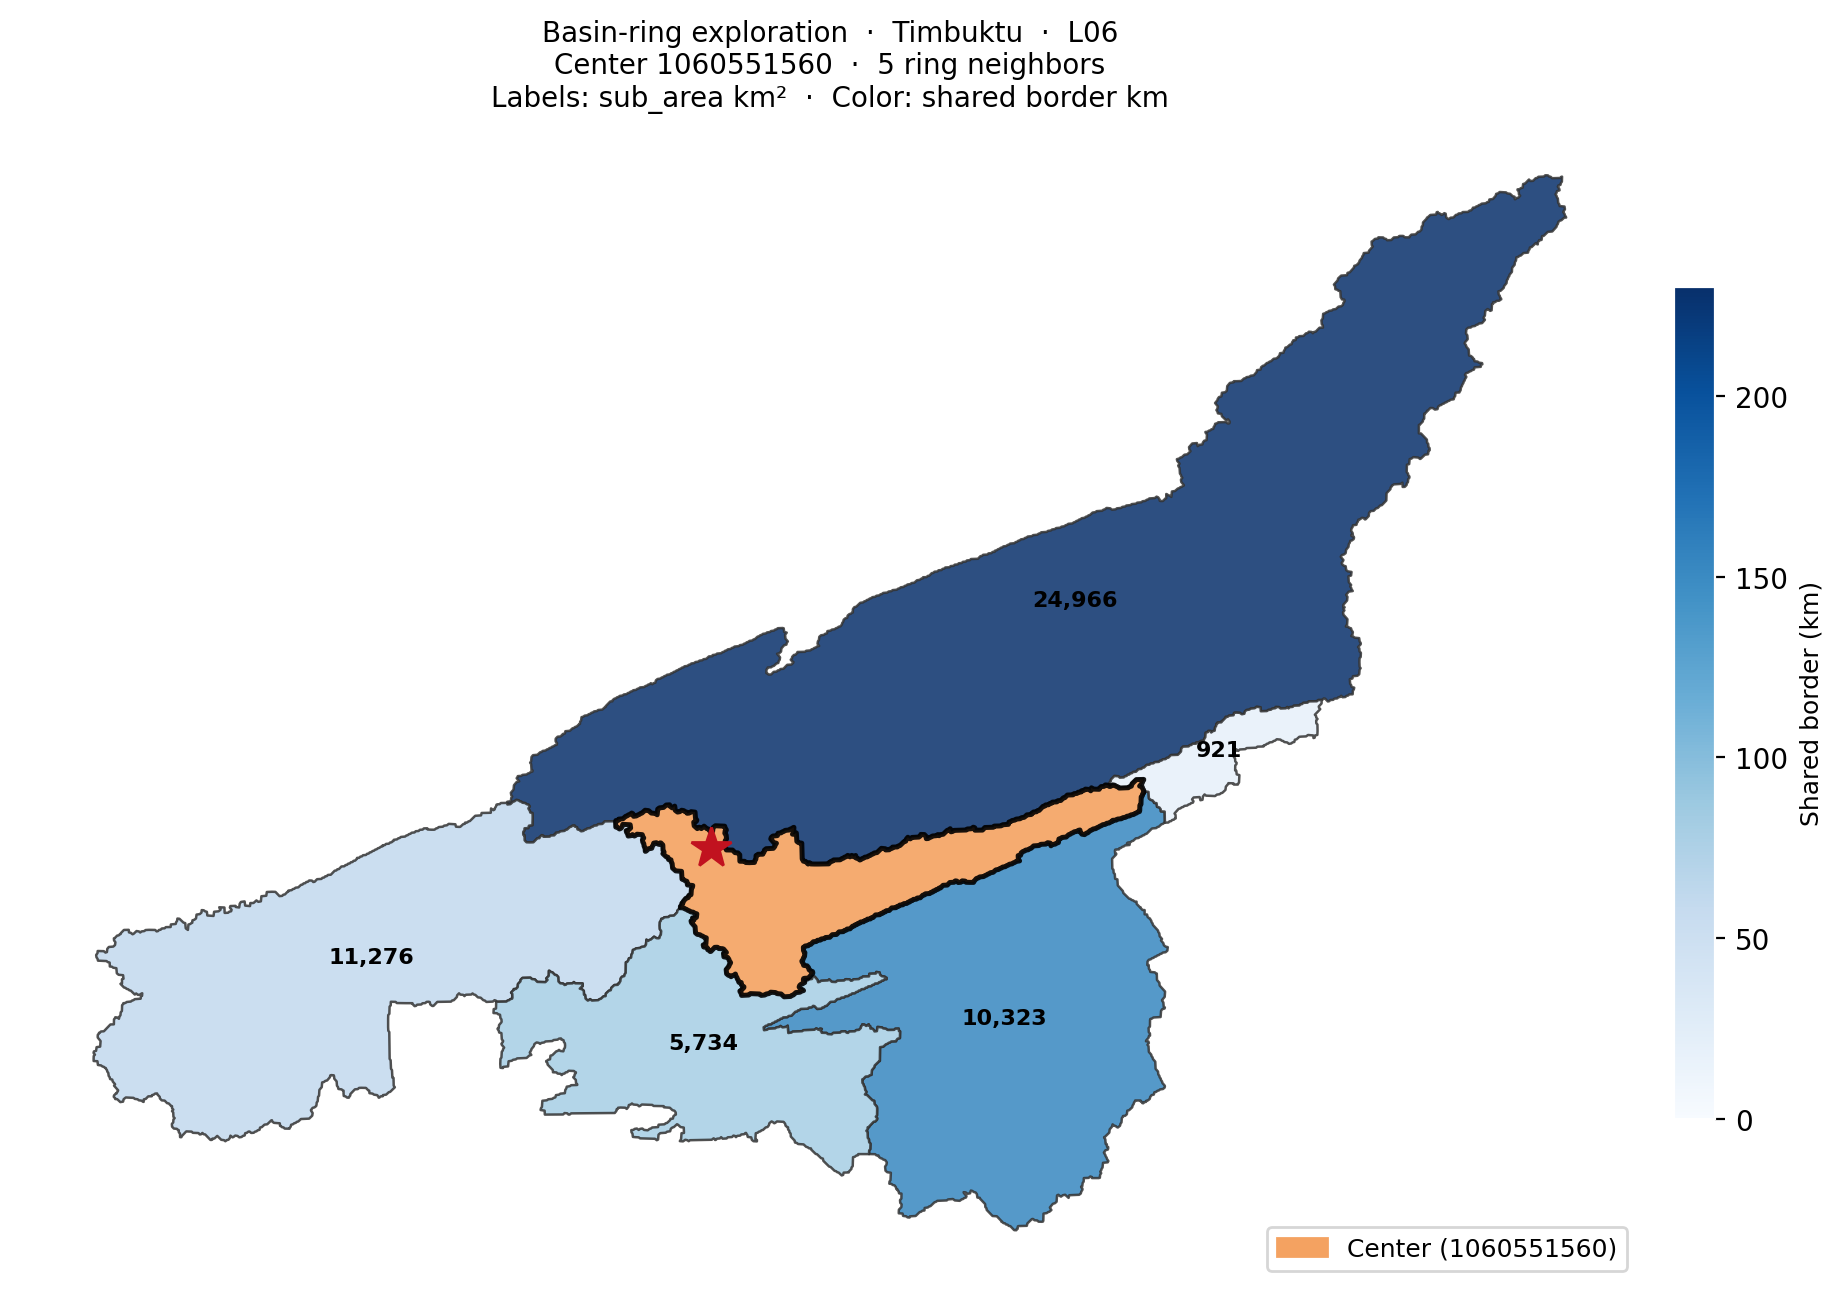

In [6]:
# Cell 6 — map: Timbuktu L06 center basin + ring (colored by shared border length)

center_wkt = conn.execute(
    f"SELECT ST_AsText(geom) FROM public.basin06 WHERE hybas_id = {CENTER_L06}"
).fetchone()[0]
center_gdf = gpd.GeoDataFrame(
    {'hybas_id': [CENTER_L06]},
    geometry=[shapely_wkt.loads(center_wkt)],
    crs='EPSG:4326'
)

vmax = ring_l06['shared_km'].max()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#d0e4f7')

ring_l06.plot(column='shared_km', ax=ax, cmap='Blues', vmin=0, vmax=vmax,
              edgecolor='#333333', linewidth=0.9, alpha=0.85)
center_gdf.plot(ax=ax, color='#f4a261', edgecolor='black', linewidth=1.8, alpha=0.9)
ax.plot(LON, LAT, marker='*', color='#c1121f', markersize=15, zorder=6, label='Query point')

for _, row in ring_l06.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, f"{row['sub_area_km2']:,.0f}", fontsize=8, ha='center',
            color='black', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='Blues', norm=Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.6)
cbar.set_label('Shared border (km)', fontsize=9, color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
cbar.ax.tick_params(colors='black')

orange_patch = mpatches.Patch(color='#f4a261', label=f'Center ({CENTER_L06})')
leg = ax.legend(handles=[orange_patch], loc='lower right', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('white')
for t in leg.get_texts():
    t.set_color('black')

ax.set_title(
    f'Basin-ring exploration  ·  Timbuktu  ·  L06\n'
    f'Center {CENTER_L06}  ·  {len(ring_l06)} ring neighbors\n'
    f'Labels: sub_area km²  ·  Color: shared border km',
    fontsize=10, color='black'
)
ax.set_axis_off()

outpath = OUT / 'wo16_ring_timbuktu_l06.png'
fig.savefig(outpath, dpi=200, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [7]:
# Cell 7 — Rome and Baghdad L06: ring queries + stats

additional_rings = {}
for fx_info in fixtures_l06:
    if fx_info['name'] == 'Timbuktu':
        continue
    name = fx_info['name']
    ring = query_ring(fx_info['hybas_id'], '06', conn)
    additional_rings[name] = ring

    vertex_n = int((ring['shared_km'] == 0).sum())
    status   = 'CLEAN' if vertex_n == 0 else 'ARTIFACT'
    print(f"=== {name} L06  (center={fx_info['hybas_id']}) ===")
    print(f"  Ring size      : {len(ring)} neighbors")
    print(f"  Contact types  : {dict(ring['shared_type'].value_counts())}")
    print(f"  Vertex-only    : {vertex_n}  {status}")
    print(f"  sub_area range : {ring['sub_area_km2'].min():,.0f} – {ring['sub_area_km2'].max():,.0f} km²")
    print(f"  shared_km range: {ring['shared_km'].min()} – {ring['shared_km'].max()}")
    print()

    summary_rows.append({
        'name': name, 'level': 'L06',
        'hybas_id': fx_info['hybas_id'],
        'center_area_km2': fx_info['sub_area_km2'],
        'n_ring': len(ring),
        'n_vertex_only': vertex_n,
        'min_sub_area_km2': ring['sub_area_km2'].min(),
        'median_sub_area_km2': ring['sub_area_km2'].median(),
        'median_shared_km': float(ring['shared_km'].median()),
    })

=== Rome L06  (center=2060015610) ===
  Ring size      : 7 neighbors
  Contact types  : {'ST_MultiLineString': np.int64(7)}
  Vertex-only    : 0  CLEAN
  sub_area range : 2,999 – 17,160 km²
  shared_km range: 23.41 – 260.48

=== Baghdad L06  (center=2060773460) ===
  Ring size      : 13 neighbors
  Contact types  : {'ST_MultiLineString': np.int64(13)}
  Vertex-only    : 0  CLEAN
  sub_area range : 666 – 20,023 km²
  shared_km range: 12.47 – 311.4



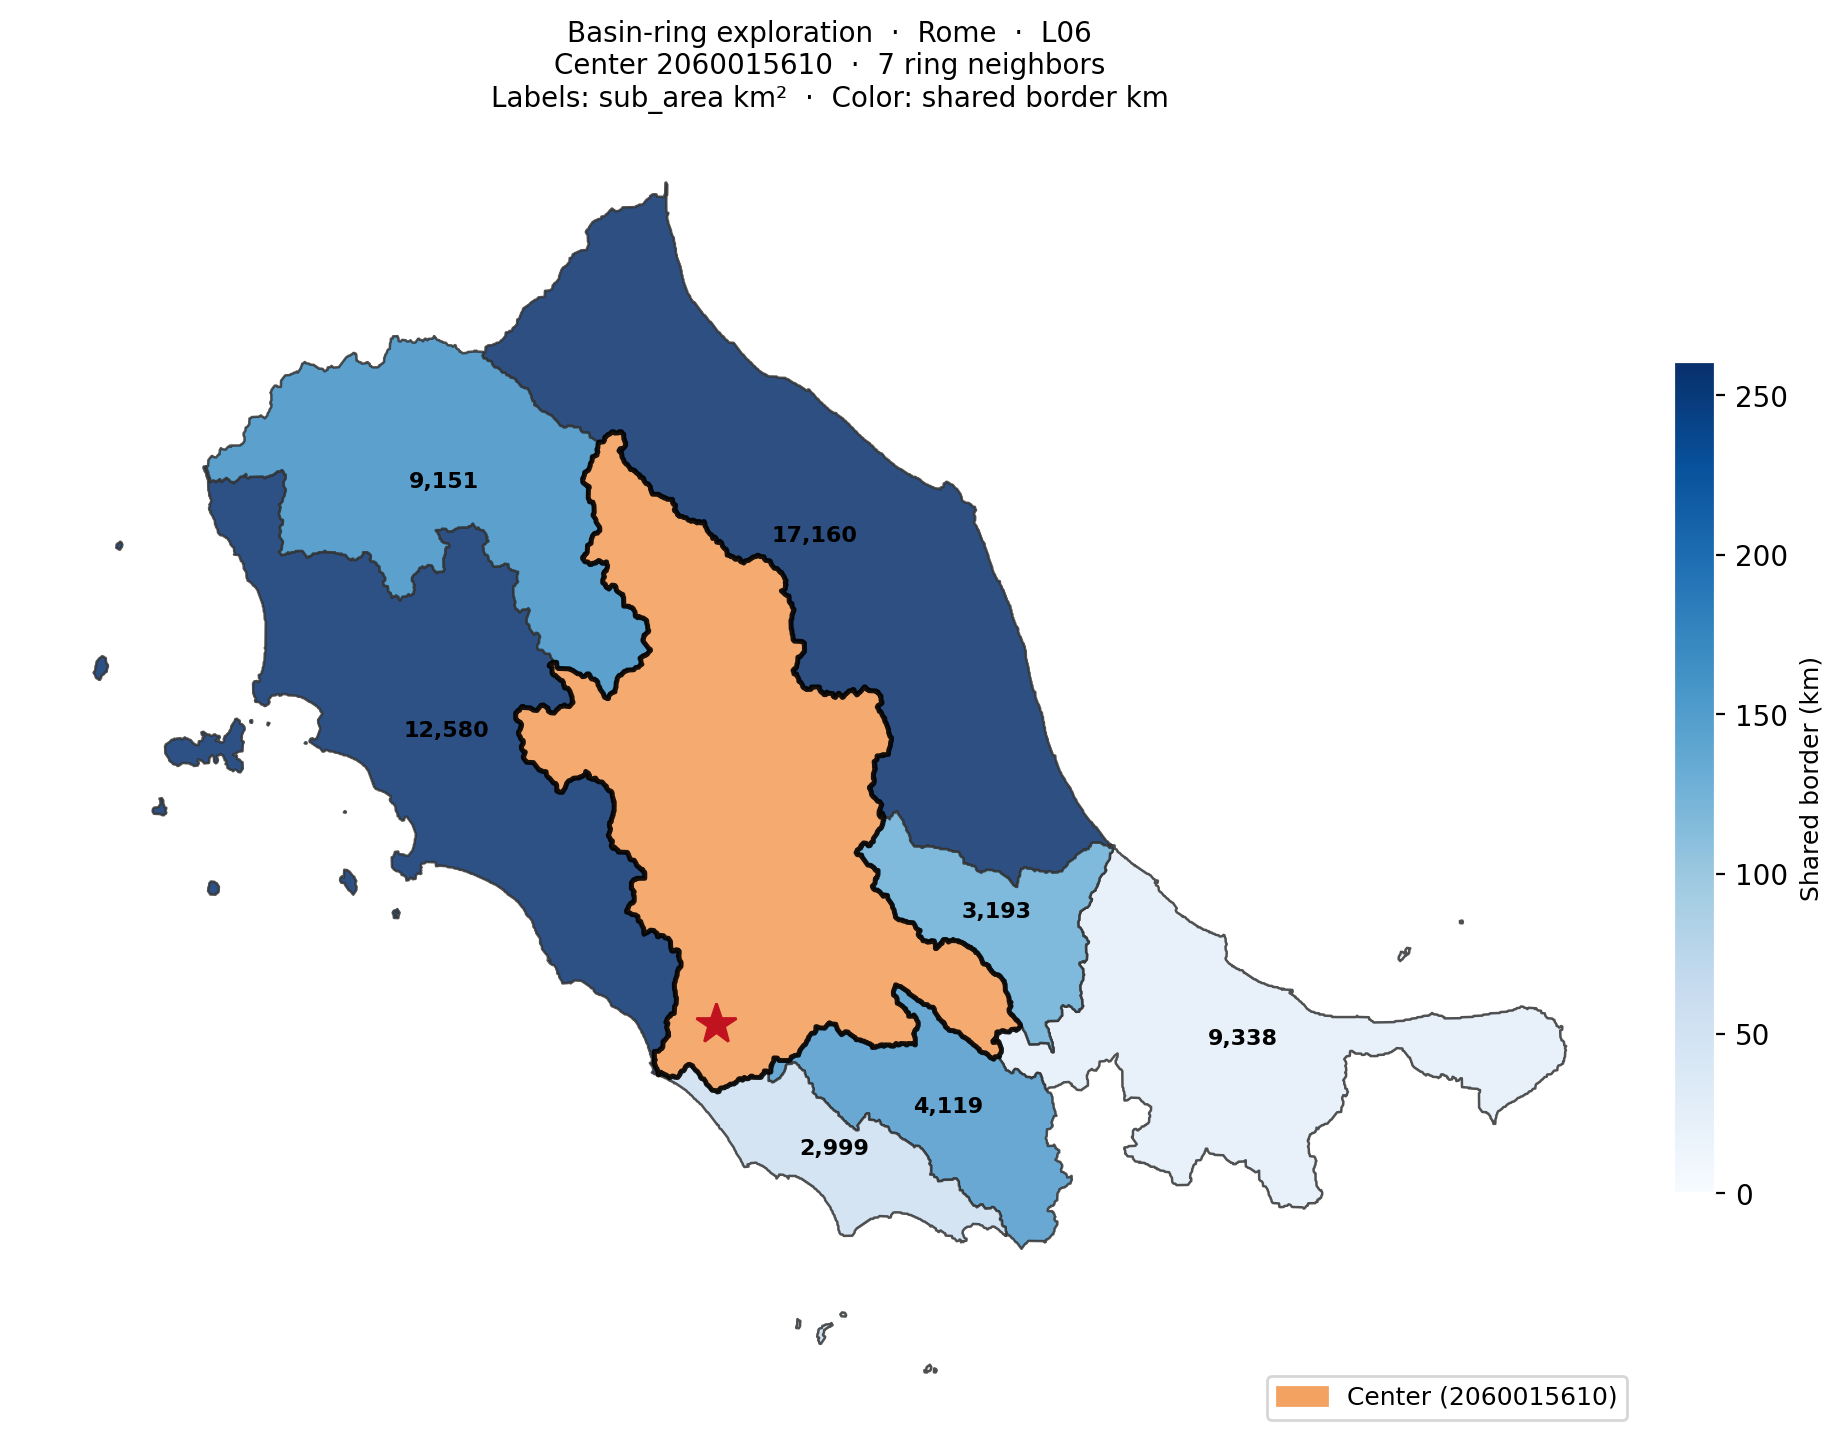

In [8]:
# Cell 8 — map: Rome L06 center basin + ring

rome_info = [r for r in fixtures_l06 if r['name'] == 'Rome'][0]
rome_ring = additional_rings['Rome']

rome_center_wkt = conn.execute(
    f"SELECT ST_AsText(geom) FROM public.basin06 WHERE hybas_id = {rome_info['hybas_id']}"
).fetchone()[0]
rome_center_gdf = gpd.GeoDataFrame(
    {'hybas_id': [rome_info['hybas_id']]},
    geometry=[shapely_wkt.loads(rome_center_wkt)],
    crs='EPSG:4326'
)

vmax = rome_ring['shared_km'].max()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#d0e4f7')

rome_ring.plot(column='shared_km', ax=ax, cmap='Blues', vmin=0, vmax=vmax,
               edgecolor='#333333', linewidth=0.9, alpha=0.85)
rome_center_gdf.plot(ax=ax, color='#f4a261', edgecolor='black', linewidth=1.8, alpha=0.9)
ax.plot(rome_info['lon'], rome_info['lat'],
        marker='*', color='#c1121f', markersize=15, zorder=6)

for _, row in rome_ring.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, f"{row['sub_area_km2']:,.0f}", fontsize=8, ha='center',
            color='black', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='Blues', norm=Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.6)
cbar.set_label('Shared border (km)', fontsize=9, color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
cbar.ax.tick_params(colors='black')

orange_patch = mpatches.Patch(color='#f4a261',
                               label=f"Center ({rome_info['hybas_id']})")
leg = ax.legend(handles=[orange_patch], loc='lower right', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('white')
for t in leg.get_texts():
    t.set_color('black')

ax.set_title(
    f"Basin-ring exploration  ·  Rome  ·  L06\n"
    f"Center {rome_info['hybas_id']}  ·  {len(rome_ring)} ring neighbors\n"
    f"Labels: sub_area km²  ·  Color: shared border km",
    fontsize=10, color='black'
)
ax.set_axis_off()

outpath = OUT / 'wo16_ring_rome_l06.png'
fig.savefig(outpath, dpi=200, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [9]:
# Cell 9 — Timbuktu L08: containing basin + ring + comparison to L06

r08 = pd.read_sql(
    f"SELECT hybas_id, sub_area AS sub_area_km2 "
    f"FROM public.basin08 "
    f"WHERE ST_Contains(geom, ST_SetSRID(ST_MakePoint({LON}, {LAT}), 4326))",
    conn
)
CENTER_L08      = int(r08['hybas_id'].iloc[0])
CENTER_L08_AREA = float(r08['sub_area_km2'].iloc[0])

timbuktu_l06_area = [r for r in fixtures_l06 if r['name'] == 'Timbuktu'][0]['sub_area_km2']
print(f'Timbuktu L08 hybas_id  : {CENTER_L08}')
print(
    f'L08 sub_area           : {CENTER_L08_AREA:,.0f} km²  '
    f'(L06 was {timbuktu_l06_area:,.0f}; ratio {timbuktu_l06_area / CENTER_L08_AREA:.1f}×)'
)
print()

ring_l08 = query_ring(CENTER_L08, '08', conn)

vertex_n_l08 = int((ring_l08['shared_km'] == 0).sum())
status       = 'CLEAN' if vertex_n_l08 == 0 else 'ARTIFACT'
print(f'=== Timbuktu L08 ring  (center={CENTER_L08}) ===')
print(f'  Ring size      : {len(ring_l08)} neighbors  (L06 had {len(ring_l06)})')
print(f"  Contact types  : {dict(ring_l08['shared_type'].value_counts())}")
print(f'  Vertex-only    : {vertex_n_l08}  {status}')
print(f"  sub_area range : {ring_l08['sub_area_km2'].min():,.0f} – {ring_l08['sub_area_km2'].max():,.0f} km²")
print(f"  shared_km range: {ring_l08['shared_km'].min()} – {ring_l08['shared_km'].max()}")
print()
print('Ring basin detail (L08):')
print(ring_l08[['hybas_id', 'sub_area_km2', 'shared_km']].to_string(index=False))

summary_rows.append({
    'name': 'Timbuktu', 'level': 'L08',
    'hybas_id': CENTER_L08,
    'center_area_km2': CENTER_L08_AREA,
    'n_ring': len(ring_l08),
    'n_vertex_only': vertex_n_l08,
    'min_sub_area_km2': ring_l08['sub_area_km2'].min(),
    'median_sub_area_km2': ring_l08['sub_area_km2'].median(),
    'median_shared_km': float(ring_l08['shared_km'].median()),
})

=== Timbuktu L08 ring  (center=1080563570) ===
  Ring size      : 7 neighbors  (L06 had 5)
  Contact types  : {'ST_MultiLineString': np.int64(7)}
  Vertex-only    : 0  CLEAN
  sub_area range : 161 – 1,659 km²
  shared_km range: 14.3 – 30.98

Ring basin detail (L08):
  hybas_id  sub_area_km2  shared_km
1080552910        1658.8      14.35
1080564950         419.8      23.33
1080551390         407.4      30.98
1080563820         251.7      22.62
1080564740         178.7      25.73
1080561810         162.5      14.30
1080550530         160.6      22.82


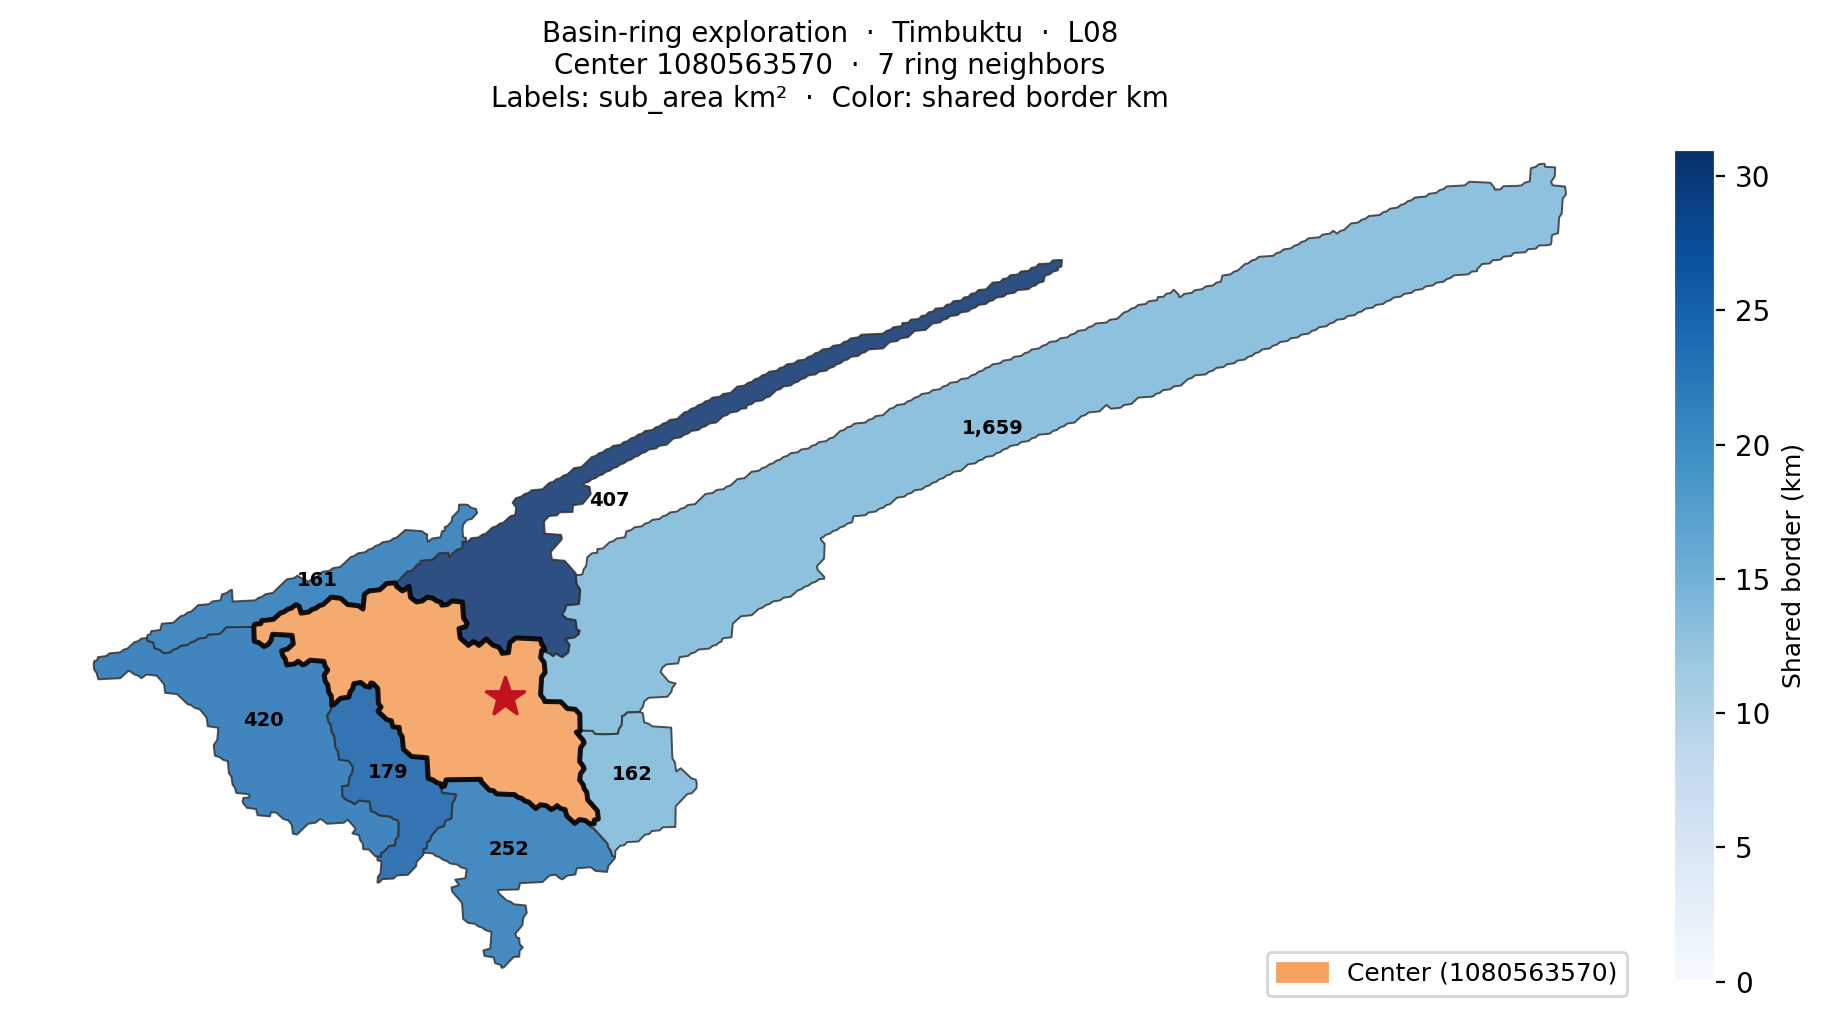

In [10]:
# Cell 10 — map: Timbuktu L08 center basin + ring

center_wkt_l08 = conn.execute(
    f"SELECT ST_AsText(geom) FROM public.basin08 WHERE hybas_id = {CENTER_L08}"
).fetchone()[0]
center_gdf_l08 = gpd.GeoDataFrame(
    {'hybas_id': [CENTER_L08]},
    geometry=[shapely_wkt.loads(center_wkt_l08)],
    crs='EPSG:4326'
)

vmax = ring_l08['shared_km'].max()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('white')
ax.set_facecolor('#d0e4f7')

ring_l08.plot(column='shared_km', ax=ax, cmap='Blues', vmin=0, vmax=vmax,
              edgecolor='#333333', linewidth=0.7, alpha=0.85)
center_gdf_l08.plot(ax=ax, color='#f4a261', edgecolor='black', linewidth=1.8, alpha=0.9)
ax.plot(LON, LAT, marker='*', color='#c1121f', markersize=15, zorder=6)

for _, row in ring_l08.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.text(cx, cy, f"{row['sub_area_km2']:,.0f}", fontsize=7, ha='center',
            color='black', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='Blues', norm=Normalize(vmin=0, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.02, shrink=0.6)
cbar.set_label('Shared border (km)', fontsize=9, color='black')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='black')
cbar.ax.tick_params(colors='black')

orange_patch = mpatches.Patch(color='#f4a261', label=f'Center ({CENTER_L08})')
leg = ax.legend(handles=[orange_patch], loc='lower right', fontsize=9, frameon=True)
leg.get_frame().set_facecolor('white')
for t in leg.get_texts():
    t.set_color('black')

ax.set_title(
    f'Basin-ring exploration  ·  Timbuktu  ·  L08\n'
    f'Center {CENTER_L08}  ·  {len(ring_l08)} ring neighbors\n'
    f'Labels: sub_area km²  ·  Color: shared border km',
    fontsize=10, color='black'
)
ax.set_axis_off()

outpath = OUT / 'wo16_ring_timbuktu_l08.png'
fig.savefig(outpath, dpi=200, bbox_inches='tight', facecolor='white')
plt.close(fig)
display(IPImage(str(outpath)))

In [11]:
# Cell 11 — cross-fixture summary + qualitative assessment

summary_df = pd.DataFrame(summary_rows)
for col in ['center_area_km2', 'min_sub_area_km2', 'median_sub_area_km2']:
    summary_df[col] = summary_df[col].round(0).astype(int)
summary_df['median_shared_km'] = summary_df['median_shared_km'].round(1)

print('=== WO16 basin-ring exploration — cross-fixture summary ===')
print()
disp = ['name', 'level', 'hybas_id', 'center_area_km2', 'n_ring',
        'n_vertex_only', 'min_sub_area_km2', 'median_sub_area_km2', 'median_shared_km']
print(summary_df[disp].to_string(index=False))
print()

# Qualitative checks
clean = True
for _, row in summary_df.iterrows():
    tag = f"{row['name']} {row['level']}"
    if row['n_vertex_only'] > 0:
        print(f"  ARTIFACT : {tag} — {row['n_vertex_only']} vertex-only contact(s)")
        clean = False
    if row['n_ring'] < 3:
        print(f"  LOW      : {tag} — only {row['n_ring']} ring neighbors")
        clean = False
    if row['min_sub_area_km2'] < 50:
        print(f"  SLIVER?  : {tag} — min ring basin {row['min_sub_area_km2']} km²")
        clean = False

if clean:
    print('All fixtures CLEAN:')
    print('  • No vertex-only contacts (all shared geometries are MultiLineString edges)')
    print('  • Sensible ring sizes across fixtures and levels')
    print('  • No sliver artifacts in ring membership')
    print()
    print('ST_Touches is a valid foundation for the basin-ring resolver.')

=== WO16 basin-ring exploration — cross-fixture summary ===

    name level   hybas_id  center_area_km2  n_ring  n_vertex_only  min_sub_area_km2  median_sub_area_km2  median_shared_km
Timbuktu   L06 1060551560             3826       5              0               921                10323              80.7
    Rome   L06 2060015610            17733       7              0              2999                 9151             154.3
 Baghdad   L06 2060773460            27142      13              0               666                 3251              51.4
Timbuktu   L08 1080563570              588       7              0               161                  252              22.8

All fixtures CLEAN:
  • No vertex-only contacts (all shared geometries are MultiLineString edges)
  • Sensible ring sizes across fixtures and levels
  • No sliver artifacts in ring membership

ST_Touches is a valid foundation for the basin-ring resolver.


In [ ]:
# Cell 13 — WO17: bearing helper + resolve_basin_ring()
#
# _bearing           : great-circle azimuth, 0=N clockwise.
# resolve_basin_ring : lat/lon → (center_df, ring_df)
#   center_df  one-row DataFrame — hybas_id (int64), weight=1.0
#   ring_df    GeoDataFrame, one row per adjacent basin:
#              hybas_id, sub_area_km2, shared_km,
#              border_bearing  (° to shared-edge midpoint — where crossing happens),
#              centroid_bearing (° to neighbor centroid — diagnostic only)
#
# Design (WO17): center is held separate, ring is never collapsed.
# No weight policy — the object is the per-neighbor comparison, not a summary.
#
# Note: neighbor_lat/lon use ST_PointOnSurface, not ST_Centroid.
# 486/16,397 L06 basins have centroids outside their own polygon (non-convex geometry).
# For those basins ST_Contains returns the wrong (adjacent) basin as the signature source.
# ST_PointOnSurface guarantees the point is inside; basin values are polygon-level
# attributes so any interior point gives the correct hybas_id and thus the correct result.
# (Confirmed: Kaifeng ring neighbor 4060579370 has centroid_inside=false.)

import math

def _bearing(lat1, lon1, lat2, lon2):
    """Great-circle bearing (° true, 0=N clockwise) from (lat1,lon1) to (lat2,lon2)."""
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dl = math.radians(lon2 - lon1)
    x = math.sin(dl) * math.cos(phi2)
    y = math.cos(phi1) * math.sin(phi2) - math.sin(phi1) * math.cos(phi2) * math.cos(dl)
    return (math.degrees(math.atan2(x, y)) + 360) % 360


def resolve_basin_ring(lat, lon, level, conn):
    """
    Point → (center_df, ring_df).

    center_df : one-row DataFrame — hybas_id (int64), weight=1.0
    ring_df   : GeoDataFrame — one row per first-order adjacent basin:
                  hybas_id, sub_area_km2, shared_km,
                  neighbor_lat, neighbor_lon (ST_PointOnSurface — guaranteed inside polygon),
                  border_mid_lat, border_mid_lon (shared-edge midpoint),
                  border_bearing, centroid_bearing,
                  geometry (neighbor polygon)

    Shortfall = 0 by construction (ring is whole basins, no clipping).
    Coastal center has fewer land neighbors — not special-cased, just noted.
    """
    table = f'public.basin{level}'

    row = conn.execute(f"""
        SELECT hybas_id,
               ST_Y(ST_Centroid(geom)) AS clat,
               ST_X(ST_Centroid(geom)) AS clon
        FROM {table}
        WHERE ST_Contains(geom, ST_SetSRID(ST_MakePoint({lon}, {lat}), 4326))
    """).fetchone()
    center_id  = int(row[0])
    center_lat = float(row[1])
    center_lon = float(row[2])

    center_df = pd.DataFrame({'hybas_id': [center_id], 'weight': [1.0]})
    center_df['hybas_id'] = center_df['hybas_id'].astype('int64')

    ring_sql = f"""
    WITH center AS (
        SELECT geom FROM {table} WHERE hybas_id = {center_id}
    )
    SELECT
        b.hybas_id,
        b.sub_area                                                    AS sub_area_km2,
        b.geom,
        ST_Y(ST_PointOnSurface(b.geom))                               AS neighbor_lat,
        ST_X(ST_PointOnSurface(b.geom))                               AS neighbor_lon,
        ST_Y(ST_Centroid(ST_Intersection(b.geom, c.geom)))            AS border_mid_lat,
        ST_X(ST_Centroid(ST_Intersection(b.geom, c.geom)))            AS border_mid_lon,
        CASE
            WHEN ST_Dimension(ST_Intersection(b.geom, c.geom)) = 1
            THEN ROUND(
                (ST_Length(ST_Intersection(b.geom, c.geom)::geography) / 1000.0)::numeric, 2
            )
            ELSE 0.0
        END AS shared_km
    FROM {table} b, center c
    WHERE ST_Touches(b.geom, c.geom)
    ORDER BY b.sub_area DESC
    """
    ring_gdf = gpd.read_postgis(ring_sql, conn, geom_col='geom').rename_geometry('geometry')
    ring_gdf['hybas_id'] = ring_gdf['hybas_id'].astype('int64')

    ring_gdf['border_bearing'] = ring_gdf.apply(
        lambda r: _bearing(center_lat, center_lon, r['border_mid_lat'], r['border_mid_lon']),
        axis=1,
    )
    ring_gdf['centroid_bearing'] = ring_gdf.apply(
        lambda r: _bearing(center_lat, center_lon, r['neighbor_lat'], r['neighbor_lon']),
        axis=1,
    )

    return center_df, ring_gdf


print('_bearing() and resolve_basin_ring() defined')

In [13]:
# Cell 14 — WO17: Timbuktu L06 ring with bearings
#
# Verify resolve_basin_ring agrees with WO16's query_ring on ring membership,
# then display the bearing table sorted N→clockwise (border_bearing).
# Also: measure border-vs-centroid bearing divergence at L06 — this is the
# first evidence on whether border_bearing matters relative to centroid_bearing.

center_df_t06, ring_t06 = resolve_basin_ring(LAT, LON, '06', conn)
center_id_t06 = int(center_df_t06['hybas_id'].iloc[0])

assert center_id_t06 == 1060551560, f'Unexpected center: {center_id_t06}'
assert len(ring_t06) == 5,          f'Expected 5 ring members, got {len(ring_t06)}'
print(f'center={center_id_t06}  ring size={len(ring_t06)}  [matches WO16]')
print()

# Sort by border_bearing for directional reading
ring_t06_sorted = ring_t06.sort_values('border_bearing').reset_index(drop=True)

disp_cols = ['hybas_id', 'sub_area_km2', 'shared_km', 'border_bearing', 'centroid_bearing']
print('Timbuktu L06 ring — sorted N→clockwise by border_bearing:')
print(ring_t06_sorted[disp_cols].round(1).to_string(index=False))
print()

# Bearing divergence: |border_bearing − centroid_bearing| per neighbor
# Wrap-around safe: map to [-180, 180] before abs
ring_t06_sorted['bearing_delta'] = (
    (ring_t06_sorted['border_bearing'] - ring_t06_sorted['centroid_bearing'] + 180) % 360 - 180
).abs().round(1)

print('Border-vs-centroid bearing delta:')
print(ring_t06_sorted[['hybas_id', 'border_bearing', 'centroid_bearing', 'bearing_delta']].round(1).to_string(index=False))
print(f'\nMax delta: {ring_t06_sorted["bearing_delta"].max():.1f}°')
print(f'Mean delta: {ring_t06_sorted["bearing_delta"].mean():.1f}°')

center=1060551560  ring size=5  [matches WO16]

Timbuktu L06 ring — sorted N→clockwise by border_bearing:
  hybas_id  sub_area_km2  shared_km  border_bearing  centroid_bearing
1060041510       24966.0      230.3             5.0              40.7
1060550540         921.4       19.3            72.0              71.8
1060551770       10322.8      153.6            91.9             131.3
1060564960        5734.4       80.7           231.2             218.9
1060564740       11275.8       61.0           277.4             260.0

Border-vs-centroid bearing delta:
  hybas_id  border_bearing  centroid_bearing  bearing_delta
1060041510             5.0              40.7           35.7
1060550540            72.0              71.8            0.2
1060551770            91.9             131.3           39.4
1060564960           231.2             218.9           12.4
1060564740           277.4             260.0           17.4

Max delta: 39.4°
Mean delta: 21.0°


In [14]:
# Cell 15 — WO17: run_signatures helper
#
# Runs single_basin_signature (Bands A-E, continuous vars only) for the center
# and each ring neighbor. Uses the neighbor centroid as the query point — the
# centroid reliably falls inside the neighbor polygon (same guarantee as the
# center point for the center basin).
#
# Returns dict: hybas_id (int) → {variable: representative_score or None}
# Continuous only (method != 'class_mixture'); categoricals handled separately.

import sys
sys.path.insert(0, '../../../..')
from scripts.edop.areas.engine import single_basin_signature

BANDS_AE = ['A', 'B', 'C', 'D', 'E']
CONTINUOUS_METHODS = {'area_weighted', 'dominant_basin', 'distribution_only', 'extreme'}


def run_signatures(center_df, ring_gdf, lat, lon, level_str, conn):
    """
    Run single_basin_signature for center + each ring neighbor.
    level_str: '06' or '08' (string, for resolve_basin_ring convention).
    Returns dict: hybas_id → {variable: representative_score}.
    """
    level_int = int(level_str)
    sigs = {}

    # Center
    cid = int(center_df['hybas_id'].iloc[0])
    payload = single_basin_signature(lat, lon, conn, level=level_int,
                                     bands=BANDS_AE, include_detail=False)
    rows = [r for r in payload['rows']
            if r.get('band') != 'T' and r['method'] in CONTINUOUS_METHODS]
    sigs[cid] = {r['variable']: r['representative_score'] for r in rows}
    print(f'  center  {cid}: {len(sigs[cid])} vars')

    # Ring neighbors — query point is the neighbor's centroid
    for _, nb in ring_gdf.iterrows():
        nid  = int(nb['hybas_id'])
        nlat = float(nb['neighbor_lat'])
        nlon = float(nb['neighbor_lon'])
        payload = single_basin_signature(nlat, nlon, conn, level=level_int,
                                         bands=BANDS_AE, include_detail=False)
        rows = [r for r in payload['rows']
                if r.get('band') != 'T' and r['method'] in CONTINUOUS_METHODS]
        sigs[nid] = {r['variable']: r['representative_score'] for r in rows}
        print(f'  neighbor {nid}: {len(sigs[nid])} vars')

    return sigs


print('run_signatures() defined')

run_signatures() defined


In [15]:
# Cell 16 — WO17: build_transition_table helper + Timbuktu L06 transition
#
# build_transition_table: (center_id, ring_sorted, sigs) → DataFrame
#   Rows = ring neighbors sorted N→clockwise by border_bearing
#   Columns = meta fields + per-variable signed divergence (center − neighbor, pp)
#   Positive = center higher; Negative = neighbor higher
#
# From this table we read (WO17 §Part 2):
#   1. Per-variable character — sharp in some directions, null in others (boundary)
#                               vs uniform (interior) vs uniformly large (outlier center)
#   2. Ring coherence — do neighbors agree or split?
#   3. Variable-group co-transition — which variables move together?

META_COLS = ['hybas_id', 'border_bearing', 'centroid_bearing', 'bearing_delta', 'shared_km']
SHARP_THR = 10.0   # pp — divergence considered directionally meaningful


def build_transition_table(center_id, ring_sorted, sigs):
    """
    Signed divergence table: center_score − neighbor_score per (neighbor, variable).
    ring_sorted: ring_gdf sorted by border_bearing, with bearing_delta column.
    """
    center_scores = sigs[center_id]
    rows = []
    for _, nb in ring_sorted.iterrows():
        nid = int(nb['hybas_id'])
        nb_scores = sigs.get(nid, {})
        row = {
            'hybas_id':        nid,
            'border_bearing':  round(nb['border_bearing'],  1),
            'centroid_bearing': round(nb['centroid_bearing'], 1),
            'bearing_delta':   round(nb.get('bearing_delta', 0), 1),
            'shared_km':       nb['shared_km'],
        }
        for var, c_score in center_scores.items():
            n_score = nb_scores.get(var)
            if c_score is not None and n_score is not None:
                row[var] = round(c_score - n_score, 1)
            else:
                row[var] = None
        rows.append(row)
    return pd.DataFrame(rows)


def transition_character(div_df, label=''):
    """
    Summarise per-variable transition character from a divergence table.
    Returns DataFrame sorted by max |divergence|.
    """
    var_cols = [c for c in div_df.columns if c not in META_COLS]
    rows = []
    for var in var_cols:
        vals = div_df[var].dropna()
        if vals.empty:
            continue
        abs_vals = vals.abs()
        rows.append({
            'variable':     var,
            'max_abs':      round(abs_vals.max(), 1),
            'mean_abs':     round(abs_vals.mean(), 1),
            'n_sharp':      int((abs_vals >= SHARP_THR).sum()),
            'sign_pattern': 'all+' if (vals > 0).all() else ('all-' if (vals < 0).all() else 'mixed'),
        })
    df = pd.DataFrame(rows).sort_values('max_abs', ascending=False).reset_index(drop=True)
    if label:
        print(f'--- {label} ---')
    print(f'  vars with ≥1 sharp transition (≥{SHARP_THR} pp): '
          f'{df[df["n_sharp"]>0]["variable"].tolist()}')
    return df


print('build_transition_table() and transition_character() defined')
print()

# --- Timbuktu L06 ---
print('=== Timbuktu L06: running signatures (center + 5 neighbors) ===')
sigs_t06 = run_signatures(center_df_t06, ring_t06_sorted, LAT, LON, '06', conn)

div_t06 = build_transition_table(center_id_t06, ring_t06_sorted, sigs_t06)

print()
print('Timbuktu L06 directional transition table (meta columns):')
print(div_t06[META_COLS].to_string(index=False))
print()

char_t06 = transition_character(div_t06, label='Timbuktu L06 — per-variable character')
print()
print('Top 20 by max |divergence|:')
print(char_t06.head(20).to_string(index=False))

  neighbor 1060564740: 41 vars

Timbuktu L06 directional transition table (meta columns):
  hybas_id  border_bearing  centroid_bearing  bearing_delta  shared_km
1060041510             5.0              40.7           35.7     230.29
1060550540            72.0              71.8            0.2      19.32
1060551770            91.9             131.3           39.4     153.56
1060564960           231.2             218.9           12.4      80.66
1060564740           277.4             260.0           17.4      61.04

--- Timbuktu L06 — per-variable character ---
  vars with ≥1 sharp transition (≥10.0 pp): ['reservoir_vol', 'wet_pct_grp1', 'pct_clay_upstream', 'wet_pct_grp2', 'precip_yr_upstream', 'river_area', 'discharge_min', 'discharge_yr', 'discharge_max', 'wet_pct_grp1_upstream', 'wet_pct_grp2_upstream', 'human_footprint_09_upstream', 'pct_sand_upstream', 'gw_table_depth', 'pasture_extent', 'cropland_extent_upstream', 'human_footprint_09', 'pop_density', 'aridity_upstream', 'pct_silt_ups

In [16]:
# Cell 17 — WO17: Rome L06 transition

ROME_LAT, ROME_LON = 41.9, 12.5

center_df_r06, ring_r06 = resolve_basin_ring(ROME_LAT, ROME_LON, '06', conn)
center_id_r06 = int(center_df_r06['hybas_id'].iloc[0])

ring_r06_sorted = ring_r06.sort_values('border_bearing').reset_index(drop=True)
ring_r06_sorted['bearing_delta'] = (
    (ring_r06_sorted['border_bearing'] - ring_r06_sorted['centroid_bearing'] + 180) % 360 - 180
).abs().round(1)

print(f'=== Rome L06 (center={center_id_r06}, ring={len(ring_r06)}) ===')
print(ring_r06_sorted[['hybas_id', 'sub_area_km2', 'shared_km',
                        'border_bearing', 'centroid_bearing', 'bearing_delta']].round(1).to_string(index=False))
print(f'\nMax bearing delta: {ring_r06_sorted["bearing_delta"].max():.1f}°')
print()

print('Running signatures...')
sigs_r06 = run_signatures(center_df_r06, ring_r06_sorted, ROME_LAT, ROME_LON, '06', conn)

div_r06  = build_transition_table(center_id_r06, ring_r06_sorted, sigs_r06)
char_r06 = transition_character(div_r06, label='Rome L06 — per-variable character')
print()
print('Top 20:')
print(char_r06.head(20).to_string(index=False))

  neighbor 2060016020: 41 vars
--- Rome L06 — per-variable character ---
  vars with ≥1 sharp transition (≥10.0 pp): ['reservoir_vol', 'slope_upstream', 'discharge_yr', 'discharge_max', 'discharge_min', 'karst_upstream', 'karst', 'river_area', 'pasture_extent', 'pasture_extent_upstream', 'pct_sand_upstream', 'pct_silt_upstream', 'cropland_extent', 'elev_min', 'elev_max', 'cropland_extent_upstream', 'stream_gradient', 'aridity_upstream', 'pct_clay_upstream', 'gw_table_depth', 'aridity', 'slope_avg', 'pct_silt', 'precip_yr_upstream']

Top 20:
                variable  max_abs  mean_abs  n_sharp sign_pattern
           reservoir_vol     85.9      74.6        6         all+
          slope_upstream     83.5      36.0        4        mixed
            discharge_yr     64.8      40.1        6         all+
           discharge_max     64.0      38.8        6         all+
           discharge_min     60.4      39.5        6         all+
          karst_upstream     59.9      36.0        4     

In [17]:
# Cell 18 — WO17: Kaifeng L06 transition
# Coordinates: 34.7972, 114.3069 (v0.3 sandbox canonical)

KAIFENG_LAT, KAIFENG_LON = 34.7972, 114.3069

center_df_k06, ring_k06 = resolve_basin_ring(KAIFENG_LAT, KAIFENG_LON, '06', conn)
center_id_k06 = int(center_df_k06['hybas_id'].iloc[0])

ring_k06_sorted = ring_k06.sort_values('border_bearing').reset_index(drop=True)
ring_k06_sorted['bearing_delta'] = (
    (ring_k06_sorted['border_bearing'] - ring_k06_sorted['centroid_bearing'] + 180) % 360 - 180
).abs().round(1)

print(f'=== Kaifeng L06 (center={center_id_k06}, ring={len(ring_k06)}) ===')
print(ring_k06_sorted[['hybas_id', 'sub_area_km2', 'shared_km',
                        'border_bearing', 'centroid_bearing', 'bearing_delta']].round(1).to_string(index=False))
print(f'\nMax bearing delta: {ring_k06_sorted["bearing_delta"].max():.1f}°')
print()

print('Running signatures...')
sigs_k06 = run_signatures(center_df_k06, ring_k06_sorted, KAIFENG_LAT, KAIFENG_LON, '06', conn)

div_k06  = build_transition_table(center_id_k06, ring_k06_sorted, sigs_k06)
char_k06 = transition_character(div_k06, label='Kaifeng L06 — per-variable character')
print()
print('Top 20:')
print(char_k06.head(20).to_string(index=False))

  neighbor 4060694190: 41 vars
--- Kaifeng L06 — per-variable character ---
  vars with ≥1 sharp transition (≥10.0 pp): ['reservoir_vol', 'elev_max', 'slope_upstream', 'river_area', 'karst_upstream', 'pasture_extent_upstream', 'discharge_max', 'discharge_yr', 'pasture_extent', 'slope_avg', 'karst', 'discharge_min', 'gw_table_depth', 'stream_gradient', 'dist_sink', 'elev_min', 'runoff', 'pct_silt', 'pct_silt_upstream', 'aridity_upstream', 'aridity', 'pct_clay']

Top 20:
               variable  max_abs  mean_abs  n_sharp sign_pattern
          reservoir_vol     97.0      65.2        5        mixed
               elev_max     52.9      13.7        3        mixed
         slope_upstream     51.0      29.9        5        mixed
             river_area     39.7      17.1        4        mixed
         karst_upstream     38.1      24.4        6         all-
pasture_extent_upstream     36.8      18.7        5        mixed
          discharge_max     35.5      22.5        6        mixed
      

In [18]:
# Cell 19 — WO17: Timbuktu L08 transition
#
# Same diagnostic at L08 to test MAUP: does the variable transition character
# change when we disaggregate to finer basins?  L08 center ≠ L06 center (different
# hybas_id level), and we expect more neighbors with narrower shared borders.
# Sharp-variable overlap between L06 and L08 is the key MAUP signal.

center_df_t08, ring_t08 = resolve_basin_ring(LAT, LON, '08', conn)
center_id_t08 = int(center_df_t08['hybas_id'].iloc[0])

assert center_id_t08 == 1080563570, f'Unexpected L08 center: {center_id_t08}'
assert len(ring_t08) == 7,          f'Expected 7 L08 ring members, got {len(ring_t08)}'
print(f'center={center_id_t08}  ring={len(ring_t08)}  [matches WO16]')
print()

ring_t08_sorted = ring_t08.sort_values('border_bearing').reset_index(drop=True)
ring_t08_sorted['bearing_delta'] = (
    (ring_t08_sorted['border_bearing'] - ring_t08_sorted['centroid_bearing'] + 180) % 360 - 180
).abs().round(1)

print('Timbuktu L08 ring — sorted N→clockwise by border_bearing:')
disp_cols = ['hybas_id', 'sub_area_km2', 'shared_km', 'border_bearing', 'centroid_bearing', 'bearing_delta']
print(ring_t08_sorted[disp_cols].round(1).to_string(index=False))
print(f'\nMax bearing delta L08: {ring_t08_sorted["bearing_delta"].max():.1f}°')
print()

print('Running L08 signatures...')
sigs_t08 = run_signatures(center_df_t08, ring_t08_sorted, LAT, LON, '08', conn)

div_t08  = build_transition_table(center_id_t08, ring_t08_sorted, sigs_t08)
char_t08 = transition_character(div_t08, label='Timbuktu L08 — per-variable character')
print()
print('Top 20:')
print(char_t08.head(20).to_string(index=False))
print()

# MAUP comparison: which sharp-transition variables appear at both levels?
sharp_t06 = set(char_t06[char_t06['n_sharp'] > 0]['variable'])
sharp_t08 = set(char_t08[char_t08['n_sharp'] > 0]['variable'])
print('Sharp-transition variable overlap — Timbuktu L06 vs L08:')
print(f'  L06 only : {sorted(sharp_t06 - sharp_t08)}')
print(f'  L08 only : {sorted(sharp_t08 - sharp_t06)}')
print(f'  Both     : {sorted(sharp_t06 & sharp_t08)}')

  neighbor 1080550530: 41 vars
--- Timbuktu L08 — per-variable character ---
  vars with ≥1 sharp transition (≥10.0 pp): ['reservoir_vol', 'dist_sink', 'discharge_min', 'discharge_yr', 'discharge_max', 'river_area', 'precip_yr_upstream', 'pasture_extent_upstream', 'pasture_extent', 'pct_sand_upstream', 'wet_pct_grp2', 'wet_pct_grp1', 'pct_silt_upstream', 'pop_density', 'pct_clay_upstream', 'human_footprint_09_upstream', 'slope_upstream', 'slope_avg', 'aridity_upstream', 'human_footprint_09', 'runoff', 'gw_table_depth']

Top 20:
                   variable  max_abs  mean_abs  n_sharp sign_pattern
              reservoir_vol     96.5      27.6        2        mixed
                  dist_sink     71.4      29.7        3        mixed
              discharge_min     71.3      28.5        3        mixed
               discharge_yr     69.6      30.7        3        mixed
              discharge_max     68.4      32.9        4        mixed
                 river_area     60.8      28.2      

In [19]:
# Cell 20 — WO17: cross-fixture summary and findings
#
# Collect and compare transition character across all fixtures.
# Questions answered here (WO17 acceptance criteria):
#   1. Does border_bearing differ meaningfully from centroid_bearing?
#      → If max delta is large at any fixture, border_bearing is non-redundant.
#   2. Which variables show directional transitions at multiple fixtures?
#      → Cross-fixture agreement = structural (not noise or local accident).
#   3. MAUP: do the same variable classes surface at L06 and L08?
#      → High overlap = scale-stable signal; low overlap = MAUP-sensitive.

print('=== WO17 cross-fixture summary ===')
print()

# Bearing delta summary across fixtures
bearing_rows = []
for label, ring_sorted in [
    ('Timbuktu L06', ring_t06_sorted),
    ('Rome L06',     ring_r06_sorted),
    ('Kaifeng L06',  ring_k06_sorted),
    ('Timbuktu L08', ring_t08_sorted),
]:
    deltas = ring_sorted['bearing_delta']
    bearing_rows.append({
        'fixture':    label,
        'n_ring':     len(ring_sorted),
        'max_delta':  round(deltas.max(), 1),
        'mean_delta': round(deltas.mean(), 1),
        'n_large':    int((deltas > 15).sum()),   # >15° = potentially misclassified direction
    })

bearing_df = pd.DataFrame(bearing_rows)
print('Border-vs-centroid bearing divergence:')
print(bearing_df.to_string(index=False))
print()

# Sharp-transition variable overlap across L06 fixtures
sharp_r06 = set(char_r06[char_r06['n_sharp'] > 0]['variable'])
sharp_k06 = set(char_k06[char_k06['n_sharp'] > 0]['variable'])

all_sharp  = sharp_t06 | sharp_r06 | sharp_k06
cross_3    = sharp_t06 & sharp_r06 & sharp_k06
cross_2    = ((sharp_t06 & sharp_r06) | (sharp_t06 & sharp_k06) | (sharp_r06 & sharp_k06)) - cross_3
one_only   = all_sharp - cross_3 - cross_2

print('Sharp-transition variable cross-fixture agreement (L06, 3 fixtures):')
print(f'  All 3 fixtures : {sorted(cross_3)}')
print(f'  Any 2 fixtures : {sorted(cross_2)}')
print(f'  1 fixture only : {sorted(one_only)}')
print()

# Per-fixture sharp-variable counts
print('Sharp-variable counts per fixture:')
for label, char_df in [
    ('Timbuktu L06', char_t06),
    ('Rome L06',     char_r06),
    ('Kaifeng L06',  char_k06),
    ('Timbuktu L08', char_t08),
]:
    sharp = char_df[char_df['n_sharp'] > 0]
    print(f'  {label:15s}: {len(sharp):2d} sharp  ({sorted(sharp["variable"].tolist())})')
print()

# MAUP summary (already printed in Cell 19; recap here)
print('MAUP — Timbuktu L06 vs L08 sharp-variable overlap:')
overlap = len(sharp_t06 & sharp_t08)
union   = len(sharp_t06 | sharp_t08)
jaccard = overlap / union if union else 0
print(f'  Overlap: {overlap}/{union} variables  (Jaccard {jaccard:.2f})')
print()

print('--- Findings for areas_findings.md (AF.14+) ---')
print()
print('[Populate after running cells 14-19 and reading the tables.]')
print('Template:')
print('  AF.14  border_bearing vs centroid_bearing divergence: ...')
print('  AF.15  Cross-fixture sharp-transition variable character: ...')
print('  AF.16  MAUP sensitivity at Timbuktu L06→L08: ...')

=== WO17 cross-fixture summary ===

Border-vs-centroid bearing divergence:
     fixture  n_ring  max_delta  mean_delta  n_large
Timbuktu L06       5       39.4        21.0        3
    Rome L06       7       27.1        13.1        3
 Kaifeng L06       7      119.8        34.9        3
Timbuktu L08       7       26.8        17.5        4

Sharp-transition variable cross-fixture agreement (L06, 3 fixtures):
  All 3 fixtures : ['aridity_upstream', 'discharge_max', 'discharge_min', 'discharge_yr', 'elev_max', 'gw_table_depth', 'pasture_extent', 'pasture_extent_upstream', 'pct_silt', 'pct_silt_upstream', 'reservoir_vol', 'river_area', 'slope_avg', 'slope_upstream', 'stream_gradient']
  Any 2 fixtures : ['aridity', 'cropland_extent_upstream', 'elev_min', 'karst', 'karst_upstream', 'pct_clay', 'pct_clay_upstream', 'pct_sand_upstream', 'precip_yr_upstream', 'runoff']
  1 fixture only : ['cropland_extent', 'dist_sink', 'human_footprint_09', 'human_footprint_09_upstream', 'pct_sand', 'pop_densi

In [12]:
# Cell 12 — close connection
conn.close()
print('Done.')

Done.
